# Figure S12 — dendrodendritic FFI, postsynaptic sensory modules

The dendrite-presynaptic counterpart of
`figure5fj_S11_postsynaptic_sensory_modules_axon.ipynb`: the same analysis restricted to
neurons postsynaptic to PSI-IhN **dendrites** (`kind == "dendrite_pre"`, ≥5 synapses),
which are the dendrodendritic FFI targets of the two Islet populations.

Feeds **Figure S12c–h**. Unlike the axon version, it contributes no main-figure panel.

It reads `../data/psi_ihn_partners_filtered_gt400_v2.csv` — the version including the
recovered dendrite-presynaptic partners (630 `dendrite_pre` rows vs 424 in the non-v2
file). Outputs go to `figureS11_outputs_dendrite_only/`. **Runs offline.**

---


In [1]:
# ============================================================
# CELL 0: Imports + config
# ============================================================
import os
import re
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Dict, List, Optional

# ----------------------------
# Paths (edit these if needed)
# ----------------------------
# NOTE: this notebook intentionally uses the _v2 CSV (per your instruction), unlike the
# axon_pre CORRECTED notebook which uses the non-_v2 file.
CSV_IN = "../data/psi_ihn_partners_filtered_gt400_v2.csv"
FEATHER_DIR = Path("../data/psi_ihn_postsynaptic_feather")
OUT_DIR = "figureS11_outputs_dendrite_only"
os.makedirs(OUT_DIR, exist_ok=True)

print("CSV exists:      ", os.path.exists(CSV_IN), "->", CSV_IN)
print("FEATHER_DIR exists:", FEATHER_DIR.exists(), "->", FEATHER_DIR)

# ----------------------------
# Which partner "kind" to analyze
# ----------------------------
KIND_VALUE = "dendrite_pre"

# ----------------------------
# Which tags to analyze -- ONLY these two, per your instruction
# ----------------------------
TAGS = ["islet-chtmr", "islet-cltmr"]

# ----------------------------
# How to collapse multiple rows that share the same (tag, post_root_id)
#   "sum"   -> total synapses this post receives from this tag (recommended default)
#   "max"   -> largest single edge
#   "first" -> just keep one row (old, possibly-wrong behavior)
# ----------------------------
AGG_NSYN = "sum"

# ----------------------------
# tag -> the ONE sensory subtype each tag is "supposed" to target
# (used for the violin/ECDF's target_frac, i.e. fraction of the tag-specific subtype)
# ----------------------------
TAG_TO_TARGET_TYPE = {
    "islet-chtmr": "C-HTMR-Non-peptidergic",
    "islet-cltmr": "C-LTMR",
}

# ----------------------------
# Feather-file classification config (same thresholds as the axon_pre notebook)
# ----------------------------
SENSORY_TYPES = [
    "Aδ-HTMR", "C-Cold", "C-HTMR", "C-HTMR-Non-peptidergic",
    "C-Heat", "Aβ-LTMR", "Aδ-LTMR", "C-LTMR",
]
LOW_CONF_LABEL = "low_confidence_sensory"
ALL_TYPES_WITH_NA = SENSORY_TYPES + ["N/A", LOW_CONF_LABEL]

# FIXED, explicit score columns -- NOT auto-detected. This is the fix for the bug in the
# original notebook's Cell 6, where an auto-detect version of this list picked up the `id`
# column (huge integer) and made the low-confidence relabel never fire.
CLASSIFIER_SCORE_COLS = ["cltmr", "abltmr", "adltmr", "chtmrnp", "c-htmr", "adhtmrp", "cheat", "cold"]
LOW_CONF_THRESH = 0.6
SELECTIVE_THRESH = 0.50
EXCLUDE_FROM_SELECTIVE = {"N/A", LOW_CONF_LABEL}

# ----------------------------
# Display / color maps -- LaTeX-superscript style labels for just these 2 tags
# ----------------------------
cell_type_display_map = {
    "islet-chtmr":  r"Islet-PSI-IhN$^{C\mathrm{-HTMR/Heat}}$ -> postsyn",
    "islet-cltmr":  r"Islet-PSI-IhN$^{C\mathrm{-LTMR}}$ -> postsyn",
}

line_color_map = {
    "islet-chtmr":  "#3C2F80",
    "islet-cltmr":  "#789342",
}

rename_map = {
    "C-Heat": "Peptidergic C-Nociceptors",
    "C-HTMR": "C-HTMR/Heat (SST)",
    "C-HTMR-Non-peptidergic": "C-HTMR/Heat (MrgprA3,MrgprD,MrgprB4)",
    LOW_CONF_LABEL: "Low-Confidence",
}
color_map = {
    "C-Cold": "#13678A",
    "Aδ-HTMR": "#F0AE44",
    "Peptidergic C-Nociceptors": "#AE7F21",
    "C-HTMR/Heat (SST)": "#ffbbff",
    "C-HTMR/Heat (MrgprA3,MrgprD,MrgprB4)": "#548D95",
    "C-LTMR": "#789342",
    "Aδ-LTMR": "#9AEBA3",
    "Aβ-LTMR": "#45C4B0",
    "Low-Confidence": "#d3d3d3",
}

def tag_display(tag: str) -> str:
    return cell_type_display_map.get(str(tag), str(tag))

def display_name(ct: str) -> str:
    return rename_map.get(ct, ct)

def display_color(ct: str) -> str:
    return color_map.get(display_name(ct), "#cccccc")

# ----------------------------
# Global plot style (Helvetica, small fonts, keep SVG text as text)
# ----------------------------
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["Helvetica", "Arial", "DejaVu Sans"]
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.size"] = 5
mpl.rcParams["axes.titlesize"] = 5
mpl.rcParams["axes.labelsize"] = 5
mpl.rcParams["xtick.labelsize"] = 5
mpl.rcParams["ytick.labelsize"] = 5


CSV exists:       True -> ../data/psi_ihn_partners_filtered_gt400_v2.csv
FEATHER_DIR exists: True -> ../data/psi_ihn_postsynaptic_feather


In [2]:
# ============================================================
# CELL 1: Helper functions (identical logic to the axon_pre CORRECTED notebook)
# ============================================================

def safe_int_from_string(s):
    """Parse a root_id that may be a string, float-like string ('...0.0'), or scientific notation."""
    if s is None or pd.isna(s):
        return None
    ss = str(s).strip()
    if ss.endswith(".0"):
        ss = ss[:-2]
    if "e" in ss.lower():
        return None
    try:
        return int(ss)
    except Exception:
        return None


def feather_path_for_root(post_id_int) -> Path:
    return FEATHER_DIR / f"cell_type_predictions_{int(post_id_int)}.feather"


def read_and_classify_post(post_id_int) -> dict:
    """
    Read ONE feather file for ONE postsynaptic neuron and classify it.

    Returns a dict with:
      status:  "missing_file" | "read_error" | "no_cell_type_columns"
               | "no_classifier_columns" | "no_sensory_data" | "ok"
      counts:  dict {sensory_type: count} (only present if status == "ok")
      denom:   int, total classifiable sensory rows (only if status == "ok")
      best_type / best_frac / is_selective: selectivity info (only if status == "ok")

    Anything with status != "ok" should be SKIPPED from every downstream figure --
    that's the single point where "missing or unusable -> skip" is enforced.
    """
    fp = feather_path_for_root(post_id_int)
    if not fp.exists():
        return {"status": "missing_file"}

    try:
        f = pd.read_feather(fp)
    except Exception:
        return {"status": "read_error"}

    if ("cell_type" not in f.columns) or ("is_sensory" not in f.columns):
        return {"status": "no_cell_type_columns"}

    missing_cls = [c for c in CLASSIFIER_SCORE_COLS if c not in f.columns]
    if missing_cls:
        return {"status": "no_classifier_columns"}

    # relabel low-confidence sensory rows using the FIXED score columns (not auto-detect)
    is_sensory_mask = f["is_sensory"] == True
    low_conf_mask = (f[CLASSIFIER_SCORE_COLS] <= LOW_CONF_THRESH).all(axis=1)
    f.loc[is_sensory_mask & low_conf_mask, "cell_type"] = LOW_CONF_LABEL

    vc = f["cell_type"].astype(str).value_counts().to_dict()

    denom = sum(int(vc.get(ct, 0)) for ct in ALL_TYPES_WITH_NA if ct != "N/A")
    if denom <= 0:
        # feather exists and was readable, but nothing classifiable in it
        # (e.g. no sensory rows at all) -- MUST be skipped, not silently kept as "ok".
        return {"status": "no_sensory_data"}

    counts = {ct: int(vc.get(ct, 0)) for ct in ALL_TYPES_WITH_NA if ct != "N/A"}

    candidates = [ct for ct in ALL_TYPES_WITH_NA if ct not in EXCLUDE_FROM_SELECTIVE and ct != "N/A"]
    fracs = {ct: counts.get(ct, 0) / float(denom) for ct in candidates}
    best_type = max(fracs, key=fracs.get)
    best_frac = fracs[best_type]
    is_sel = best_frac >= SELECTIVE_THRESH

    return {
        "status": "ok",
        "counts": counts,
        "denom": denom,
        "fracs": fracs,
        "best_type": best_type,
        "best_frac": best_frac,
        "is_selective": bool(is_sel),
        "selective_type": best_type if is_sel else None,
    }


In [3]:
# ============================================================
# CELL 2: Build the ONE canonical (tag, post_root_id) table, restricted to
# kind == "dendrite_pre" and to islet-chtmr / islet-cltmr.
# Every figure below reads from this table and nothing else.
# ============================================================

raw = pd.read_csv(
    CSV_IN,
    dtype={"tag": "string", "pre_root_id": "string", "post_root_id": "string", "kind": "string"},
)
need = {"tag", "post_root_id", "kind", "n_synapses"}
missing_cols = need - set(raw.columns)
if missing_cols:
    raise ValueError(f"CSV missing required columns: {missing_cols}")

sub = raw[(raw["kind"] == KIND_VALUE) & (raw["tag"].isin(TAGS))].copy()
sub["n_synapses"] = pd.to_numeric(sub["n_synapses"], errors="coerce")
sub["post_id"] = sub["post_root_id"].apply(safe_int_from_string)
sub = sub[sub["post_id"].notna()].copy()
sub["post_id"] = sub["post_id"].astype(int)

n_raw_rows = len(sub)

# ---- THE dedup step: collapse multiple edges of the same tag onto the same post ----
grouped = (
    sub.groupby(["tag", "post_id"])
    .agg(n_synapses=("n_synapses", AGG_NSYN), n_edges=("post_id", "size"))
    .reset_index()
)
n_unique_pairs = len(grouped)

print(f"[{KIND_VALUE}] raw rows (before dedup):        {n_raw_rows}")
print(f"[{KIND_VALUE}] unique (tag, post_id) pairs:     {n_unique_pairs}")
print(f"  -> {n_raw_rows - n_unique_pairs} rows collapsed by the (tag, post_id) dedup "
      f"(n_synapses aggregated with '{AGG_NSYN}')")

# ---- ONE feather read per unique post_id (classifier scores don't depend on tag) ----
unique_posts = sorted(grouped["post_id"].unique().tolist())
post_cache: Dict[int, dict] = {}
for pid in unique_posts:
    post_cache[pid] = read_and_classify_post(pid)

status_series = grouped["post_id"].map(lambda pid: post_cache[pid]["status"])
grouped["status"] = status_series

def _target_frac(row):
    info = post_cache[row["post_id"]]
    if info["status"] != "ok":
        return np.nan
    target_type = TAG_TO_TARGET_TYPE.get(row["tag"])
    if target_type is None:
        return np.nan
    return info["fracs"].get(target_type, np.nan)

grouped["target_frac"] = grouped.apply(_target_frac, axis=1)
grouped["is_selective"] = grouped["post_id"].map(
    lambda pid: post_cache[pid]["is_selective"] if post_cache[pid]["status"] == "ok" else np.nan
)
grouped["selective_type"] = grouped["post_id"].map(
    lambda pid: post_cache[pid]["selective_type"] if post_cache[pid]["status"] == "ok" else None
)

canonical_df = grouped.copy()

# ----------------------------
# Diagnostics: exactly why each post was kept or dropped, per tag
# ----------------------------
print("\n" + "=" * 70)
print("Per-tag breakdown (this is the SAME filter used by every figure below)")
print("=" * 70)
for tag in TAGS:
    g = canonical_df[canonical_df["tag"] == tag]
    counts_by_status = g["status"].value_counts().to_dict()
    n_ok = counts_by_status.get("ok", 0)
    print(f"\n{tag_display(tag)}  ({tag})")
    print(f"  Unique postsynaptic neurons (post_root_id): {len(g)}")
    for status, n in sorted(counts_by_status.items(), key=lambda kv: -kv[1]):
        tag_note = "  <- kept, used by all 4 figures" if status == "ok" else "  <- skipped"
        print(f"    {status:22s}: {n:4d}{tag_note}")

canonical_csv_path = os.path.join(OUT_DIR, f"canonical_post_sensory_table__{KIND_VALUE}.csv")
canonical_df.to_csv(canonical_csv_path, index=False)
print(f"\nSaved canonical table to: {canonical_csv_path}")


[dendrite_pre] raw rows (before dedup):        595
[dendrite_pre] unique (tag, post_id) pairs:     296
  -> 299 rows collapsed by the (tag, post_id) dedup (n_synapses aggregated with 'sum')

Per-tag breakdown (this is the SAME filter used by every figure below)

Islet-PSI-IhN$^{C\mathrm{-HTMR/Heat}}$ -> postsyn  (islet-chtmr)
  Unique postsynaptic neurons (post_root_id): 134
    ok                    :  133  <- kept, used by all 4 figures
    missing_file          :    1  <- skipped

Islet-PSI-IhN$^{C\mathrm{-LTMR}}$ -> postsyn  (islet-cltmr)
  Unique postsynaptic neurons (post_root_id): 162
    ok                    :  162  <- kept, used by all 4 figures

Saved canonical table to: figureS11_outputs_dendrite_only/canonical_post_sensory_table__dendrite_pre.csv


Saved: figureS11_outputs_dendrite_only/violin_islet-chtmr__dendrite_pre.svg   (n plotted = 133 )


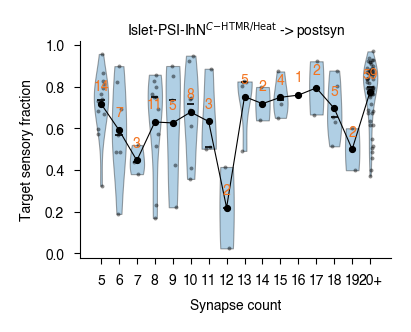

Saved: figureS11_outputs_dendrite_only/violin_islet-cltmr__dendrite_pre.svg   (n plotted = 162 )


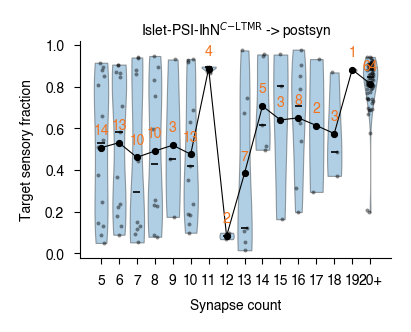

In [4]:
# ============================================================
# CELL 3: FIGURE 1 -- Violin plots (target_frac vs n_synapses), one per tag
# Uses ONLY canonical_df rows with status == "ok"
#
# TAIL_BIN_THRESH carries over your original notebook's choice of 20 for both
# tags, but binning now uses ">=" (not the original notebook's strict ">"),
# to match the semantics used in the axon_pre CORRECTED notebook. If you'd
# rather keep the original strict ">" behavior, change the comparison in
# _apply_tail_binning below.
# ============================================================

MIN_N_PER_BIN = 2
JITTER = 0.18
DOT_SIZE = 2
DOT_ALPHA = 0.45
N_LABEL_COLOR = "#f37420"

TAIL_BIN_THRESH = {
    "islet-chtmr": 20,
    "islet-cltmr": 20,
}

CM = 1 / 2.54
FIG_SIZE_IN = (5 * CM, 4 * CM)

def _apply_tail_binning(sub_df, tag, xcol="n_synapses"):
    sub_df = sub_df.copy()
    thr = TAIL_BIN_THRESH.get(tag)
    if thr is None:
        return sub_df
    # NOTE: ">=" so the bin exactly at threshold is folded into "thr+"
    sub_df[xcol] = np.where(sub_df[xcol] >= thr, thr, sub_df[xcol])
    return sub_df

def _safe_basename(s):
    return "".join(c if c.isalnum() or c in ("-", "_") else "_" for c in s)

violin_ok = canonical_df[canonical_df["status"] == "ok"].dropna(subset=["n_synapses", "target_frac"]).copy()

violin_ns = {}  # tag -> total n plotted, for the cross-figure summary at the end

for tag in TAGS:
    sub = violin_ok[violin_ok["tag"] == tag][["n_synapses", "target_frac"]].copy()
    sub["n_synapses"] = sub["n_synapses"].round().astype(int)
    sub = _apply_tail_binning(sub, tag, "n_synapses")

    fig, ax = plt.subplots(figsize=FIG_SIZE_IN, dpi=200)

    if sub.empty:
        ax.text(0.5, 0.5, f"No data for {tag}", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        violin_ns[tag] = 0
    else:
        xs = np.sort(sub["n_synapses"].unique())
        data = [sub.loc[sub["n_synapses"] == x, "target_frac"].values for x in xs]
        counts = np.array([len(d) for d in data])
        keep = counts >= MIN_N_PER_BIN
        xs_keep, data_keep = xs[keep], [d for d, k in zip(data, keep) if k]

        if len(xs_keep) > 0:
            parts = ax.violinplot(data_keep, positions=xs_keep.astype(float), widths=0.8,
                                   showmeans=False, showmedians=True, showextrema=False)
            for pc in parts["bodies"]:
                pc.set_alpha(0.35); pc.set_linewidth(0.4); pc.set_edgecolor("black")
            parts["cmedians"].set_linewidth(0.6); parts["cmedians"].set_color("black")

        rng = np.random.default_rng(0)
        for x in xs:
            y = sub.loc[sub["n_synapses"] == x, "target_frac"].values
            jitter = rng.uniform(-JITTER, JITTER, size=len(y))
            ax.scatter(np.full_like(y, x, dtype=float) + jitter, y, s=DOT_SIZE, alpha=DOT_ALPHA,
                       linewidths=0, color="black", zorder=3)

        means = sub.groupby("n_synapses")["target_frac"].mean().reindex(xs).values
        ax.plot(xs, means, marker="o", markersize=1.6, linewidth=0.4, color="black", zorder=4)

        for x in xs:
            n = int((sub["n_synapses"] == x).sum())
            y_mean = float(sub.loc[sub["n_synapses"] == x, "target_frac"].mean())
            ax.text(x, min(1.02, y_mean + 0.05), str(n), ha="center", va="bottom",
                    fontsize=5, color=N_LABEL_COLOR, zorder=5)

        thr = TAIL_BIN_THRESH.get(tag)
        xticklabels = [f"{int(thr)}+" if (thr is not None and int(x) == int(thr)) else str(int(x)) for x in xs]
        ax.set_xticks(xs); ax.set_xticklabels(xticklabels)

        violin_ns[tag] = int(len(sub))

    ax.set_title(tag_display(tag), pad=2)
    ax.set_xlabel("Synapse count")
    ax.set_ylabel("Target sensory fraction")
    ax.set_ylim(-0.02, 1.02)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.4)
    ax.spines["bottom"].set_linewidth(0.4)
    ax.tick_params(axis="both", width=0.4, length=2)
    plt.tight_layout(pad=0.4)

    save_path = os.path.join(OUT_DIR, f"violin_{_safe_basename(tag)}__{KIND_VALUE}.svg")
    fig.savefig(save_path, format="svg")
    print("Saved:", save_path, "  (n plotted =", violin_ns[tag], ")")
    plt.show()


Saved: figureS11_outputs_dendrite_only/ecdf_target_sensory_fraction__dendrite_pre.svg
  islet-chtmr: n = 133
  islet-cltmr: n = 162


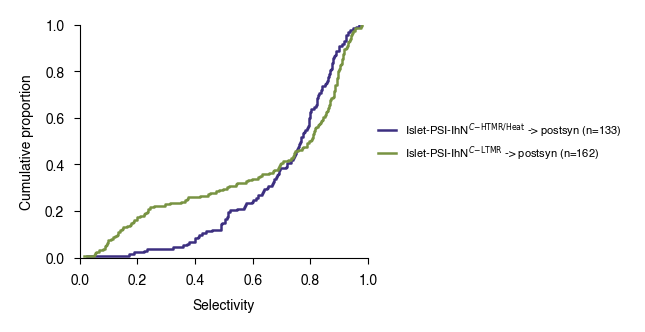

In [5]:
# ============================================================
# CELL 4: FIGURE 2 -- ECDF of target_frac, both tags on one plot
# Uses ONLY canonical_df rows with status == "ok"
# ============================================================

def ecdf(arr: np.ndarray):
    x = np.sort(arr.astype(float))
    n = len(x)
    if n == 0:
        return np.array([]), np.array([])
    y = np.arange(1, n + 1, dtype=float) / float(n)
    return x, y

CM = 1 / 2.54
fig, ax = plt.subplots(figsize=(8 * CM, 4 * CM), dpi=200)

ecdf_ns = {}
ecdf_ok = canonical_df[canonical_df["status"] == "ok"].dropna(subset=["target_frac"]).copy()

for tag in TAGS:
    arr = ecdf_ok.loc[ecdf_ok["tag"] == tag, "target_frac"].values.astype(float)
    xs, ys = ecdf(arr)
    ecdf_ns[tag] = int(len(arr))
    if len(xs) == 0:
        continue
    lab = f"{tag_display(tag)} (n={len(xs)})"
    ax.step(xs, ys, where="post", linewidth=0.9, label=lab, color=line_color_map.get(tag))

ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
ax.set_xlabel("Selectivity")
ax.set_ylabel("Cumulative proportion")
ax.set_title("")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.4)
ax.spines["bottom"].set_linewidth(0.4)
ax.tick_params(axis="both", width=0.4, length=2)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=4, frameon=False,
          handlelength=1.6, labelspacing=0.4, borderaxespad=0.0)
fig.subplots_adjust(right=0.72)
plt.tight_layout(pad=0.4)

save_path = os.path.join(OUT_DIR, f"ecdf_target_sensory_fraction__{KIND_VALUE}.svg")
fig.savefig(save_path, format="svg")
print("Saved:", save_path)
for tag in TAGS:
    print(f"  {tag}: n = {ecdf_ns[tag]}")
plt.show()


Saved: figureS11_outputs_dendrite_only/islet-chtmr__selectivity__dendrite_pre.svg


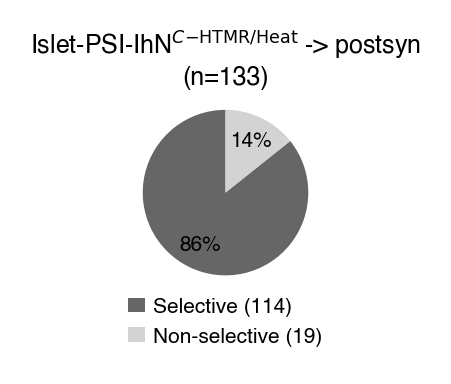

Saved: figureS11_outputs_dendrite_only/islet-chtmr__composition__dendrite_pre.svg


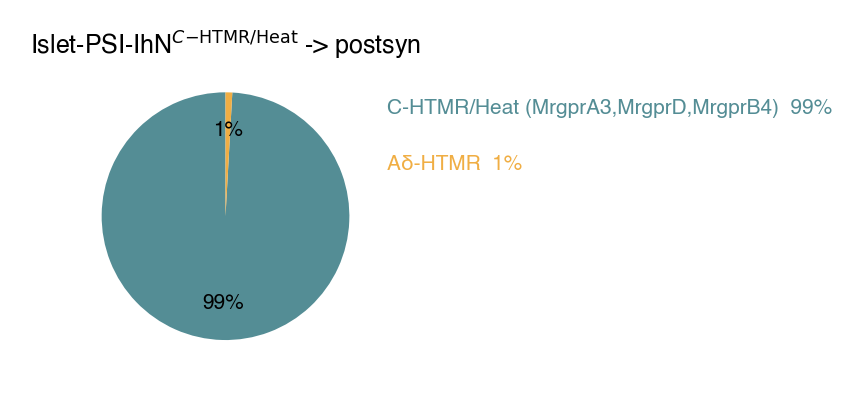

Saved: figureS11_outputs_dendrite_only/islet-cltmr__selectivity__dendrite_pre.svg


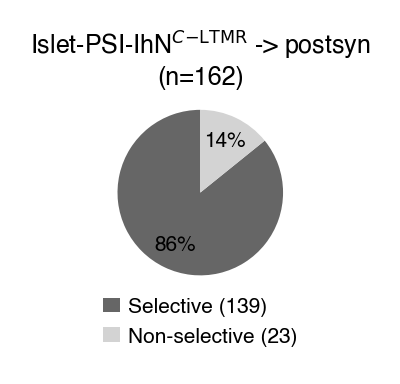

Saved: figureS11_outputs_dendrite_only/islet-cltmr__composition__dendrite_pre.svg


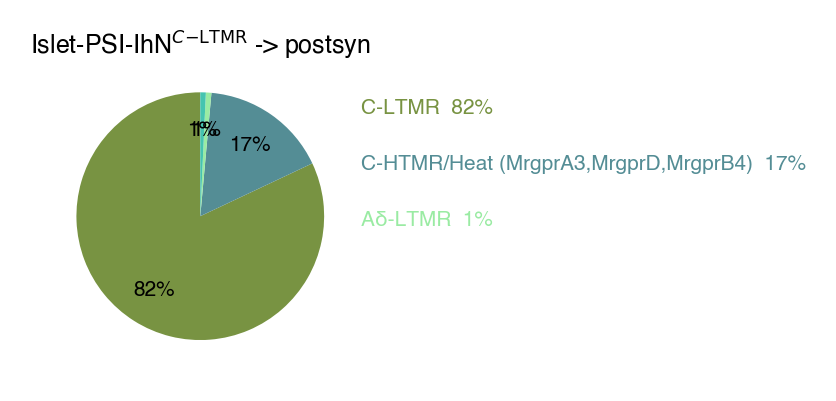

In [6]:
# ============================================================
# CELL 5: FIGURE 3 -- Pie charts (selective vs non-selective, + subtype
# breakdown among selective), one pair per tag.
# Uses ONLY canonical_df rows with status == "ok"  (SAME filter as violin/ECDF)
#
# This is also the fix for the original notebook's Cell 7 bug, where
# denom <= 0 posts were silently kept as "ok" (inflating n). Here those posts
# already got status="no_sensory_data" in Cell 2 and are excluded.
# ============================================================

CM_TO_IN = 1.0 / 2.54
FIG_SIZE_CM = (4, 3)
TOPK = 3

pie_ns = {}
pie_ok = canonical_df[canonical_df["status"] == "ok"].copy()

def _outside_topk_text(ax, counts: pd.Series, topk: int, fontsize: float = 5):
    top = counts.head(topk)
    total = float(counts.sum()) if float(counts.sum()) > 0 else 1.0
    for i, (k, v) in enumerate(top.items()):
        frac = float(v) / total
        ax.text(1.02, 0.85 - i * 0.18, f"{display_name(k)}  {frac*100:.0f}%",
                transform=ax.transAxes, ha="left", va="center",
                fontsize=fontsize, color=display_color(k), clip_on=False)

for tag in TAGS:
    g = pie_ok[pie_ok["tag"] == tag]
    n_total = len(g)
    n_sel = int(g["is_selective"].sum())
    n_non = n_total - n_sel
    pie_ns[tag] = n_total

    fig_w, fig_h = FIG_SIZE_CM[0] * CM_TO_IN, FIG_SIZE_CM[1] * CM_TO_IN

    # ---- left: selective vs non-selective ----
    fig1, ax1 = plt.subplots(1, 1, figsize=(fig_w, fig_h), dpi=300)
    wedges, _, autotexts = ax1.pie(
        [n_sel, n_non], startangle=90, colors=["#666666", "#d3d3d3"], labels=None,
        autopct="%1.0f%%", pctdistance=0.70, textprops={"fontsize": 5},
    )
    ax1.set_title(f"{tag_display(tag)}\n(n={n_total})", fontsize=6, pad=1)
    ax1.legend(wedges, [f"Selective ({n_sel})", f"Non-selective ({n_non})"],
               loc="lower center", bbox_to_anchor=(0.5, -0.28), fontsize=5, frameon=False,
               handlelength=0.8, handletextpad=0.4, borderaxespad=0.0)
    fig1.tight_layout(pad=0.15)
    out_left = os.path.join(OUT_DIR, f"{_safe_basename(tag)}__selectivity__{KIND_VALUE}.svg")
    fig1.savefig(out_left, format="svg")
    print("Saved:", out_left)
    plt.show()

    # ---- right: composition among selective posts ----
    fig2, ax2 = plt.subplots(1, 1, figsize=(fig_w, fig_h), dpi=300)
    if n_sel > 0:
        subtype_counts = g.loc[g["is_selective"] == True, "selective_type"].astype(str).value_counts()
        colors2 = [display_color(k) for k in subtype_counts.index]
        ax2.pie(subtype_counts.values, startangle=90, colors=colors2, labels=None,
                autopct="%1.0f%%", pctdistance=0.70, textprops={"fontsize": 5})
        ax2.set_title(tag_display(tag), fontsize=6, pad=1)
        _outside_topk_text(ax2, subtype_counts, topk=TOPK)
        fig2.tight_layout(pad=0.15)
        fig2.subplots_adjust(right=0.80)
    else:
        ax2.pie([1], colors=["#d3d3d3"], labels=None)
        ax2.set_title(tag_display(tag), fontsize=6, pad=1)
        fig2.tight_layout(pad=0.15)

    out_right = os.path.join(OUT_DIR, f"{_safe_basename(tag)}__composition__{KIND_VALUE}.svg")
    fig2.savefig(out_right, format="svg")
    print("Saved:", out_right)
    plt.show()


Saved: figureS11_outputs_dendrite_only/post_syn_sensory_composition__dendrite_pre.svg


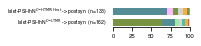

In [7]:
# ============================================================
# CELL 6: FIGURE 4 -- Stacked horizontal bar chart of sensory composition
# (one row per tag, ONLY islet-chtmr / islet-cltmr).
# Uses ONLY canonical_df rows with status == "ok"
#
# This is also the fix for the original notebook's Cell 6 bug, where an
# auto-detect version of the score-column list swept in the `id` column and
# made the low-confidence (grey) segment almost never appear.
#
# Segments are drawn with edgecolor="none", linewidth=0 (no white gaps between
# segments), per your request.
# ============================================================

sensory_columns = [
    "C-Cold", "Aδ-HTMR", "C-Heat", "C-HTMR",
    "C-HTMR-Non-peptidergic", "C-LTMR", "Aδ-LTMR",
    "Aβ-LTMR", LOW_CONF_LABEL,
]

bar_ok = canonical_df[canonical_df["status"] == "ok"].copy()
bar_ns = {}

# Pull the raw per-post sensory counts back out of post_cache and sum them per tag
# (pooled-sum aggregation: every classified partner from every post counts once).
rows = []
for _, r in bar_ok.iterrows():
    info = post_cache[r["post_id"]]
    row = {"tag": r["tag"]}
    row.update({ct: info["counts"].get(ct, 0) for ct in sensory_columns})
    rows.append(row)
comp_df = pd.DataFrame(rows)
for ct in sensory_columns:
    if ct not in comp_df.columns:
        comp_df[ct] = 0

grouped_counts = comp_df.groupby("tag")[sensory_columns].sum()
for tag in TAGS:
    bar_ns[tag] = int((bar_ok["tag"] == tag).sum())

CM = 1 / 2.54
fig_w, fig_h = 4 * CM, 0.5 * CM * len(TAGS)
fig, axes = plt.subplots(nrows=len(TAGS), ncols=1, figsize=(fig_w, fig_h), sharex=True)
if len(TAGS) == 1:
    axes = [axes]
fig.subplots_adjust(left=0.32, right=0.995, top=0.98, bottom=0.30, hspace=0.35)

for idx, tag in enumerate(TAGS):
    ax = axes[idx]
    if tag not in grouped_counts.index:
        ax.set_axis_off()
        continue
    row = grouped_counts.loc[tag].rename(rename_map)
    total = float(row.sum())
    if total <= 0:
        ax.set_axis_off()
        continue
    props = (row / total).sort_values(ascending=False)

    left = 0.0
    for lbl, val in props.items():
        # `lbl` is already a display name here (row was renamed via rename_map above),
        # and color_map is keyed by display names, so look it up directly.
        ax.barh(0, float(val) * 100.0, left=left, color=color_map.get(lbl, "#cccccc"),
                edgecolor="none", linewidth=0)
        left += float(val) * 100.0

    ax.set_xlim(0, 100)
    ax.set_yticks([])
    ax.annotate(f"{tag_display(tag)}  (n={bar_ns[tag]})", xy=(0.0, 0.5), xycoords="axes fraction",
                xytext=(-6, 0), textcoords="offset points", ha="right", va="center",
                fontsize=5, fontname="Helvetica", clip_on=False)

    if idx < len(TAGS) - 1:
        ax.get_xaxis().set_visible(False)
        for sp in ax.spines.values():
            sp.set_visible(False)
    else:
        ax.set_xticks([0, 25, 50, 75, 100])
        ax.tick_params(axis="x", labelsize=6)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)
        ax.spines["bottom"].set_visible(True)

save_path = os.path.join(OUT_DIR, f"post_syn_sensory_composition__{KIND_VALUE}.svg")
fig.savefig(save_path, format="svg")
print("Saved:", save_path)
plt.show()


In [8]:
# ============================================================
# CELL 7: Sanity check -- confirm all four figures now agree on "n" per tag
# ============================================================

summary = pd.DataFrame({
    "tag": TAGS,
    "n_canonical_ok": [int((canonical_df[(canonical_df["tag"] == t) & (canonical_df["status"] == "ok")]).shape[0]) for t in TAGS],
    "n_violin": [violin_ns.get(t, 0) for t in TAGS],
    "n_ecdf": [ecdf_ns.get(t, 0) for t in TAGS],
    "n_pie": [pie_ns.get(t, 0) for t in TAGS],
    "n_bar": [bar_ns.get(t, 0) for t in TAGS],
})
print(summary.to_string(index=False))
print()
all_match = (summary[["n_canonical_ok", "n_pie", "n_bar"]].nunique(axis=1) == 1).all()
print("n_canonical_ok == n_pie == n_bar for every tag:", bool(all_match))
print("(n_violin / n_ecdf can be slightly lower than the others only if some posts are also")
print(" missing n_synapses or target_frac -- otherwise they should match too.)")


        tag  n_canonical_ok  n_violin  n_ecdf  n_pie  n_bar
islet-chtmr             133       133     133    133    133
islet-cltmr             162       162     162    162    162

n_canonical_ok == n_pie == n_bar for every tag: True
(n_violin / n_ecdf can be slightly lower than the others only if some posts are also
 missing n_synapses or target_frac -- otherwise they should match too.)


In [9]:
# ============================================================
# CELL 8: Summary -- postsynaptic neuron counts, selectivity, and subtype
# breakdown for islet-chtmr and islet-cltmr (dendrite_pre), using canonical_df.
# (Same summary you asked for earlier, now driven off the single canonical table
# instead of a separately-computed tag_post_ok.)
# ============================================================

summary_rows = []

print("=" * 70)
print("Postsynaptic neuron summary (dendrite_pre): islet-chtmr vs islet-cltmr")
print("=" * 70)

summary_ok = canonical_df[canonical_df["status"] == "ok"].copy()

for tag in TAGS:
    g = summary_ok[summary_ok["tag"] == tag]
    n_total = len(g)
    n_sel = int(g["is_selective"].sum())
    n_non_sel = n_total - n_sel

    print(f"\n{tag_display(tag)}  ({tag})")
    print(f"  Total postsynaptic neurons: {n_total}")
    if n_total > 0:
        print(f"  Selective (>= {SELECTIVE_THRESH:.0%} target-type fraction): "
              f"{n_sel} ({n_sel / n_total:.1%})")
    else:
        print(f"  Selective: {n_sel}")
    print(f"  Non-selective: {n_non_sel}")

    row = {"tag": tag, "n_total_postsyn": n_total, "n_selective": n_sel, "n_non_selective": n_non_sel}

    if n_sel > 0:
        subtype_counts = g.loc[g["is_selective"] == True, "selective_type"].astype(str).value_counts()
        print("  Selective, broken down by sensory subtype:")
        for subtype, count in subtype_counts.items():
            print(f"    {display_name(subtype):45s} {count:4d}  ({count / n_sel:.1%} of selective)")
            row[f"selective_{subtype}"] = int(count)
    else:
        print("  Selective, broken down by sensory subtype: (none)")

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).fillna(0)
print("\n" + "=" * 70)
print("Summary table")
print("=" * 70)
print(summary_df.to_string(index=False))


Postsynaptic neuron summary (dendrite_pre): islet-chtmr vs islet-cltmr

Islet-PSI-IhN$^{C\mathrm{-HTMR/Heat}}$ -> postsyn  (islet-chtmr)
  Total postsynaptic neurons: 133
  Selective (>= 50% target-type fraction): 114 (85.7%)
  Non-selective: 19
  Selective, broken down by sensory subtype:
    C-HTMR/Heat (MrgprA3,MrgprD,MrgprB4)           113  (99.1% of selective)
    Aδ-HTMR                                          1  (0.9% of selective)

Islet-PSI-IhN$^{C\mathrm{-LTMR}}$ -> postsyn  (islet-cltmr)
  Total postsynaptic neurons: 162
  Selective (>= 50% target-type fraction): 139 (85.8%)
  Non-selective: 23
  Selective, broken down by sensory subtype:
    C-LTMR                                         114  (82.0% of selective)
    C-HTMR/Heat (MrgprA3,MrgprD,MrgprB4)            23  (16.5% of selective)
    Aδ-LTMR                                          1  (0.7% of selective)
    Aβ-LTMR                                          1  (0.7% of selective)

Summary table
        tag  n_total

In [10]:
# ============================================================
# How many neurons in the whole v4_gnn feather folder are "selective"
# (>= SELECTIVE_THRESH of their sensory input from one subtype)?
#
# This scans EVERY feather file in FEATHER_DIR directly -- not just the
# postsynaptic partners that show up in the CSV -- using the same
# read_and_classify_post() logic (fixed classifier columns, low-confidence
# relabeling, denom<=0 skipped) already defined above.
# ============================================================

import re

feather_files = sorted(Path(FEATHER_DIR).glob("*.feather"))
print(f"Feather files found in {FEATHER_DIR}: {len(feather_files)}")

all_rows = []
skipped_by_status = {}

for fp in feather_files:
    m = re.search(r"(\d+)", fp.stem)
    if not m:
        skipped_by_status["unparseable_filename"] = skipped_by_status.get("unparseable_filename", 0) + 1
        continue
    pid = int(m.group(1))

    info = read_and_classify_post(pid)
    status = info["status"]
    if status != "ok":
        skipped_by_status[status] = skipped_by_status.get(status, 0) + 1
        continue

    all_rows.append({
        "post_id": pid,
        "is_selective": info["is_selective"],
        "selective_type": info["selective_type"],
        "best_type": info["best_type"],
        "best_frac": info["best_frac"],
    })

all_df = pd.DataFrame(all_rows)

n_total = len(all_df)
n_sel = int(all_df["is_selective"].sum()) if n_total else 0
n_non = n_total - n_sel

print("\n" + "=" * 70)
print(f"Neurons classified (status == 'ok'): {n_total}")
for status, n in sorted(skipped_by_status.items(), key=lambda kv: -kv[1]):
    print(f"  skipped ({status}): {n}")
print("=" * 70)

if n_total > 0:
    print(f"\nSelective (>= {SELECTIVE_THRESH:.0%} of one sensory subtype): "
          f"{n_sel} ({n_sel / n_total:.1%})")
    print(f"Non-selective: {n_non} ({n_non / n_total:.1%})")

    if n_sel > 0:
        print("\nSelective neurons broken down by preferred sensory subtype:")
        subtype_counts = all_df.loc[all_df["is_selective"], "selective_type"].astype(str).value_counts()
        for subtype, count in subtype_counts.items():
            print(f"    {display_name(subtype):45s} {count:5d}  ({count / n_sel:.1%} of selective)")
else:
    print("No classifiable neurons found.")

Feather files found in ../data/psi_ihn_postsynaptic_feather: 1553

Neurons classified (status == 'ok'): 1553

Selective (>= 50% of one sensory subtype): 1198 (77.1%)
Non-selective: 355 (22.9%)

Selective neurons broken down by preferred sensory subtype:
    Aβ-LTMR                                         343  (28.6% of selective)
    C-HTMR/Heat (MrgprA3,MrgprD,MrgprB4)            248  (20.7% of selective)
    C-LTMR                                          233  (19.4% of selective)
    Aδ-LTMR                                         205  (17.1% of selective)
    Aδ-HTMR                                         137  (11.4% of selective)
    C-Cold                                           22  (1.8% of selective)
    Peptidergic C-Nociceptors                         9  (0.8% of selective)
    C-HTMR/Heat (SST)                                 1  (0.1% of selective)
